# **Movie Revenue Predictor Dashboard**

**Objective**
- Predict movie revenue using machine learning
- Build an interactive dashboard for predictions and insights


**Imports**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import ast

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import pickle 
import os

import streamlit as st

**Dataset Import**

In [2]:
df=pd.read_csv(r"C:\Users\Siya Anand\Downloads\dataset_1_collected_data.csv")

**Dataset Description**

- Source: Kaggle (https://www.kaggle.com/datasets/ashenp/tmdb-box-office-dataset-for-prediction?utm )
- **Original Dataset Size:** 9999 rows X 15 columns
- **Final Cleaned Dataset Size:** 4604 rows X 15 columns
- Reasons for Data Removal/ Cleaning:
    - Contained null values: 91 in total
    - Contained 0 values especially in revenue (4432) and budget (4774) columns
    - Contained duplicate entries: 232 in total



**Basic Inspection**

In [3]:
print(df.info(),'\n')
print(df.describe(),'\n')
print(df.isnull().sum(),'\n')
print(df.duplicated().sum())
print((df['budget'] == 0).sum())
print((df['revenue'] == 0).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9999 non-null   int64  
 1   title                 9999 non-null   object 
 2   budget                9999 non-null   int64  
 3   revenue               9999 non-null   int64  
 4   genres                9999 non-null   object 
 5   runtime               9999 non-null   int64  
 6   release_date          9977 non-null   object 
 7   production_companies  9999 non-null   object 
 8   production_countries  9999 non-null   object 
 9   cast                  9999 non-null   object 
 10  director              9930 non-null   object 
 11  vote_average          9999 non-null   float64
 12  vote_count            9999 non-null   int64  
 13  popularity            9999 non-null   float64
 14  original_language     9999 non-null   object 
dtypes: float64(2), int64(

**Data Cleaning**

- Missing values found
- Duplicate removal
- Movies with budget = 0 removed
- Movies with revenue = 0 removed


In [4]:
print('Initial Shape of the Dataset: ',df.shape,'\n')
df.dropna(inplace=True)
print('Shape of the Dataset after Removing Rows with Null Values: ',df.shape,'\n')
df['revenue'] = df['revenue'].replace(0, np.nan)
df['budget'] = df['budget'].replace(0, np.nan)
df.dropna(inplace=True)
print('Shape of the Dataset after Removing Rows with 0 Values from Revenue and Budget Columns: ',df.shape,'\n')
df.drop_duplicates(inplace=True)
print('Shape of the Dataset after Removing Duplicate Rows: ',df.shape,'\n')


Initial Shape of the Dataset:  (9999, 15) 

Shape of the Dataset after Removing Rows with Null Values:  (9914, 15) 

Shape of the Dataset after Removing Rows with 0 Values from Revenue and Budget Columns:  (4696, 15) 

Shape of the Dataset after Removing Duplicate Rows:  (4604, 15) 



**Dataset Description after Data Cleaning**

The dataset contains 4,604 movies and 15 original features including:
- Budget
- Revenue
- Genres
- Runtime
- Release Date
- Vote Average
- Vote Count
- Popularity
- Director
- Cast

Target Variable:
- Revenue (transformed using log_revenue for modelling)

*Extracting Release Year and Month from the release_date Column*

In [5]:
# Convert to datetime format
df['release_date'] = pd.to_datetime(df['release_date'])
# Extract year and month
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df[['release_date','release_year','release_month']].head()

,release_date,release_year,release_month
0,2025-03-31,2025,3
3,2025-03-26,2025,3
5,2025-02-12,2025,2
9,2025-01-13,2025,1
10,2024-12-18,2024,12


*Convert string representation of list to actual list*

In [6]:
genre_df = df.copy()
genre_df['genres'] = genre_df['genres'].apply(ast.literal_eval)

# Create one row per genre
genre_df = genre_df.explode('genres')
genre_df['genres'].head()

0       Family
0       Comedy
0    Adventure
0      Fantasy
3       Action
Name: genres, dtype: object

**Exploratory Data Analysis (EDA)**

*Graph-1: Revenue Distribution*

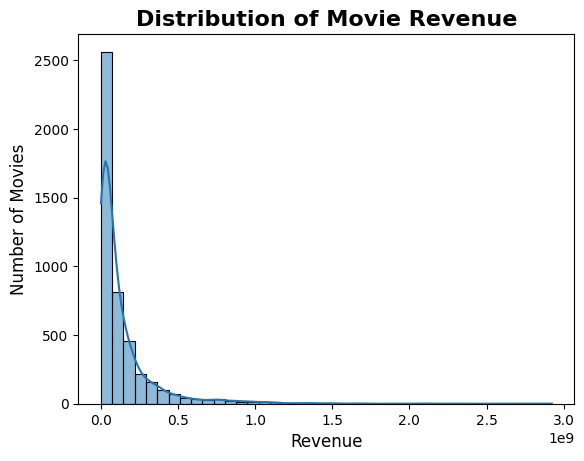

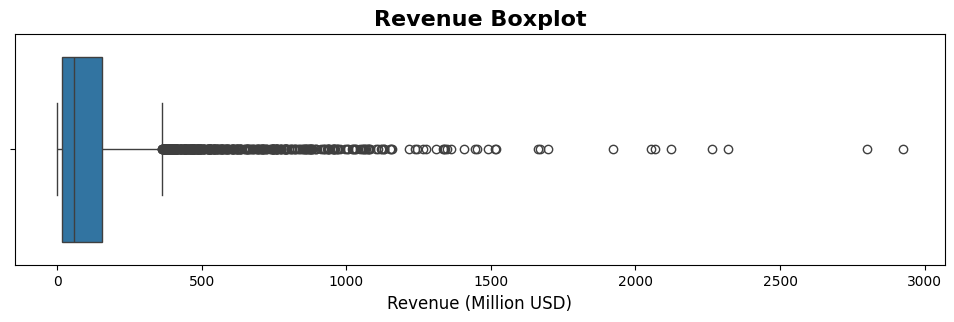

In [7]:
# Histogram for Revenue
sns.histplot(data=df,x='revenue',bins=40,kde=True)
plt.title('Distribution of Movie Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Revenue',fontsize=12)
plt.ylabel('Number of Movies',fontsize=12)
plt.show()

df['revenue_million'] = df['revenue'] / 1_000_000
# Plotting the boxplot for revenue in millions
plt.figure(figsize=(12,3))
sns.boxplot(x=df['revenue_million'])
plt.title('Revenue Boxplot',fontsize=16,fontweight='bold')
plt.xlabel('Revenue (Million USD)',fontsize=12)
plt.show()

**Observation**
- The distribution is heavily right-skewed (positively skewed).
- Most movies are concentrated in the lower revenue range.
- The number of movies decreases rapidly as revenue increases.
- A small number of movies generate extremely high revenue, creating a long tail on the right side of the distribution.
- Several high-revenue movies appear as outliers (blockbusters).

*Graph-2: Budget vs Revenue*

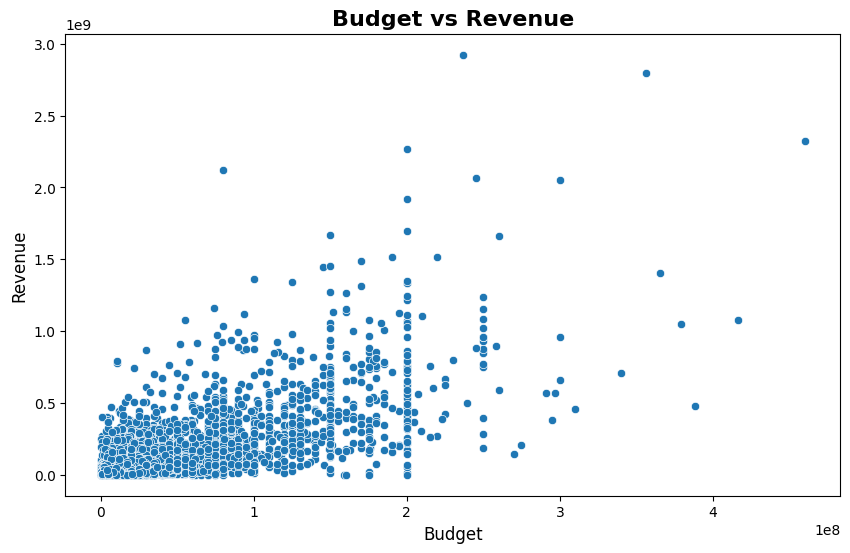

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='budget', y='revenue')
plt.xlabel('Budget',fontsize=12)
plt.ylabel('Revenue',fontsize=12)
plt.title('Budget vs Revenue',fontsize=16,fontweight='bold')
plt.show()

**Observation**
- The scatter plot shows a positive relationship between budget and revenue.
- Movies with higher budgets generally tend to generate higher revenue.
- Low-budget movies are concentrated in the lower revenue region.
- As the budget increases, the spread of revenue also increases.
- Several high-budget movies achieve extremely high revenue, while some high-budget movies still generate only moderate returns.
- The data points are widely scattered, indicating that budget alone does not fully determine a movie's success.

Graph-3: Genre Analysis

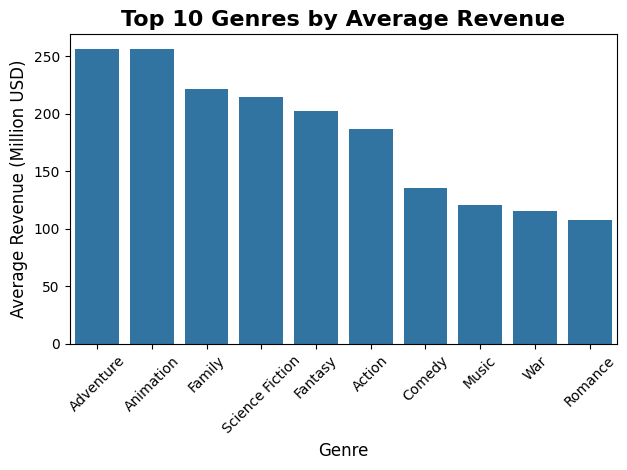

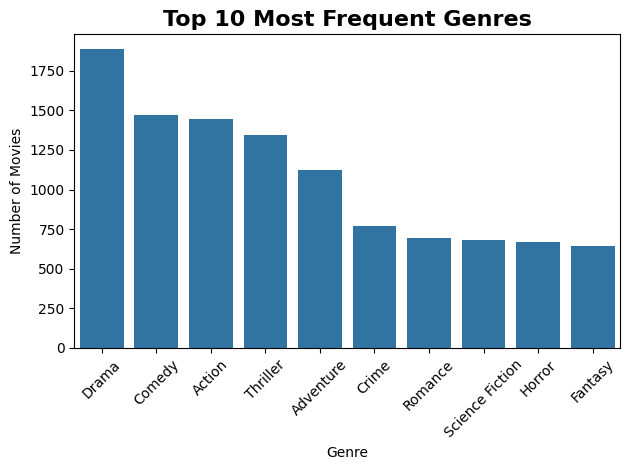

In [9]:
# Average revenue by genre
genre_revenue = (
    genre_df.groupby('genres')['revenue']
            .mean()
            .sort_values(ascending=False)
            .head(10)
            / 1_000_000
)
# Plotting the bar chart for average revenue by genre
sns.barplot(x=genre_revenue.index,y=genre_revenue.values)
plt.title('Top 10 Genres by Average Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Genre',fontsize=12)
plt.ylabel('Average Revenue (Million USD)',fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Most frequent genres
genre_counts = (genre_df['genres'].value_counts().head(10))
sns.barplot(x=genre_counts.index,y=genre_counts.values)
plt.title('Top 10 Most Frequent Genres',fontsize=16,fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**
- Drama is the most frequently occurring genre in the dataset, followed by Comedy, Action, and Thriller.
- Despite being the most common genre, Drama does not generate the highest average revenue.
- Adventure and Animation genres have the highest average revenue, even though they appear less frequently than Drama and Comedy.
- Family, Fantasy, Science Fiction, and Action movies also show strong average revenue performance.
- The results indicate that the most frequently produced genres are not necessarily the most profitable genres.

*Chart-4: Rating vs Revenue*

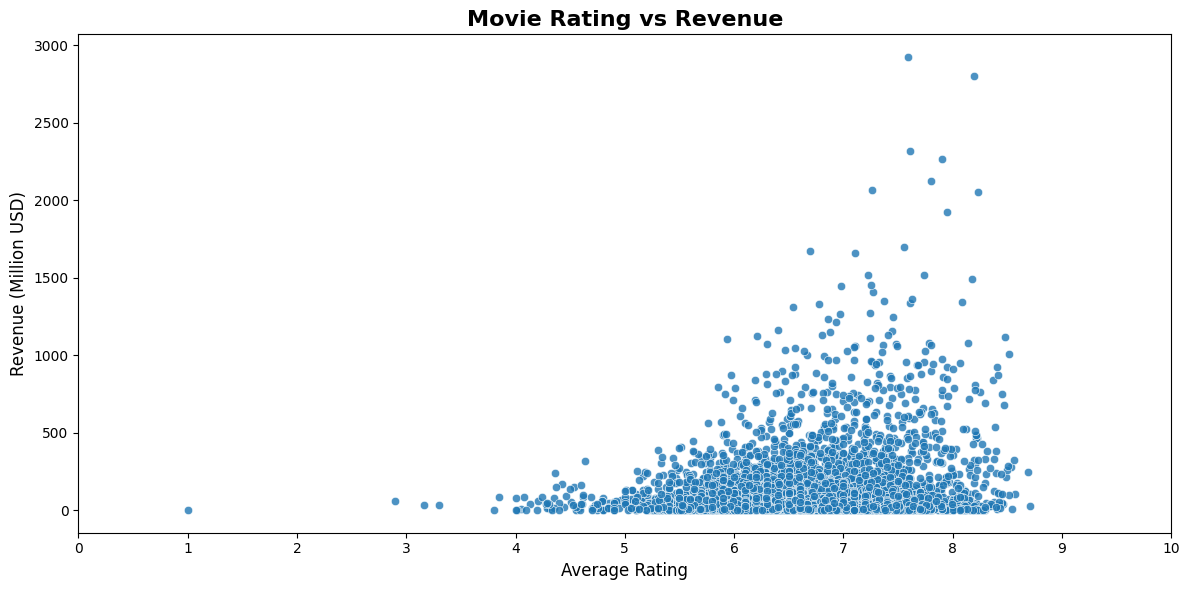

In [10]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='vote_average',y=df['revenue']/1_000_000,alpha=0.8)
plt.title('Movie Rating vs Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Average Rating',fontsize=12)
plt.ylabel('Revenue (Million USD)', fontsize=12)
plt.xticks(np.arange(0, 11, 1))
plt.yticks(np.arange(0, 3001, 500))
plt.tight_layout()
plt.show()

**Observation**
- Most movies have ratings between 6 and 8, indicating that the majority of films receive moderately positive audience ratings.
- Higher-rated movies generally tend to achieve higher revenue, suggesting a positive relationship between rating and revenue.
- The highest revenue-generating movies are mostly concentrated in the rating range of 6.5 to 8.0.
- Several movies with ratings around 7–8 generate extremely high revenue (over 1 billion USD).
- There are also many highly rated movies with relatively low revenue, indicating that rating alone does not determine commercial success.

*Chart-5: Popularity vs Revenue*

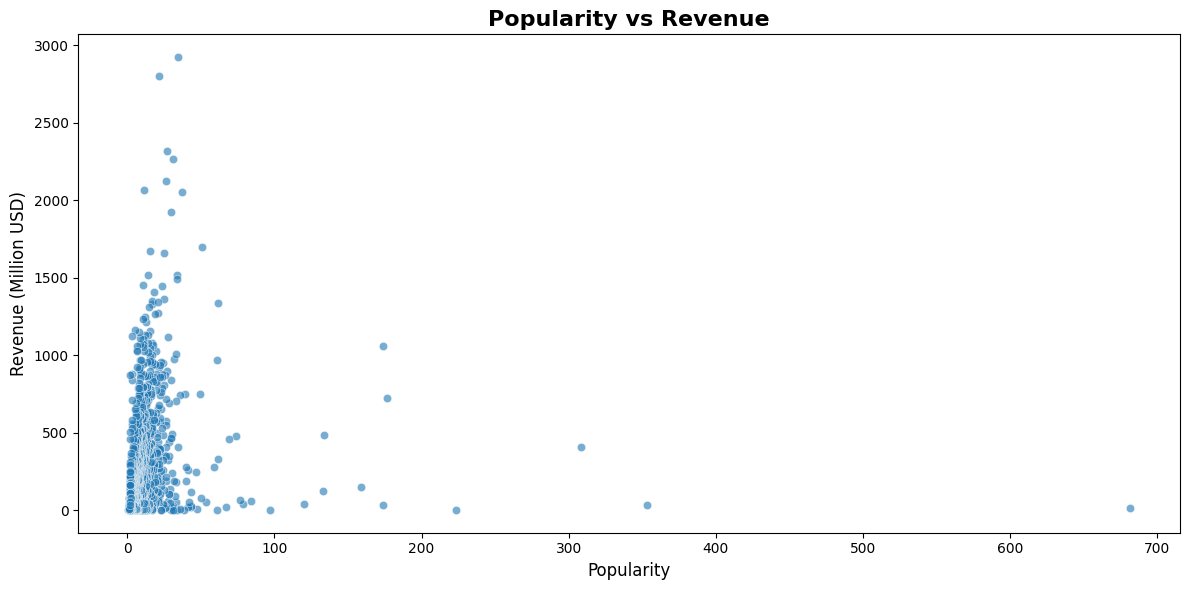

In [11]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='popularity',y=df['revenue']/1_000_000,alpha=0.6)
plt.title('Popularity vs Revenue',fontsize=16,fontweight='bold')
plt.xlabel('Popularity',fontsize=12)
plt.ylabel('Revenue (Million USD)',fontsize=12)
plt.yticks(np.arange(0, 3001, 500))
plt.tight_layout()
plt.show()

**Observation**
- Most movies are concentrated in the lower popularity range (0–50).
- Several movies with low to moderate popularity still generate significant revenue.
- Some highly popular movies achieve very high revenue, exceeding 1000 million USD.
- The relationship between popularity and revenue appears positive, but it is not perfectly linear.
- A few movies have extremely high popularity values (100–700+) but do not necessarily generate the highest revenue.
- The dataset contains several outliers in both popularity and revenue.

*Chart-6: Correlation Heatmap*

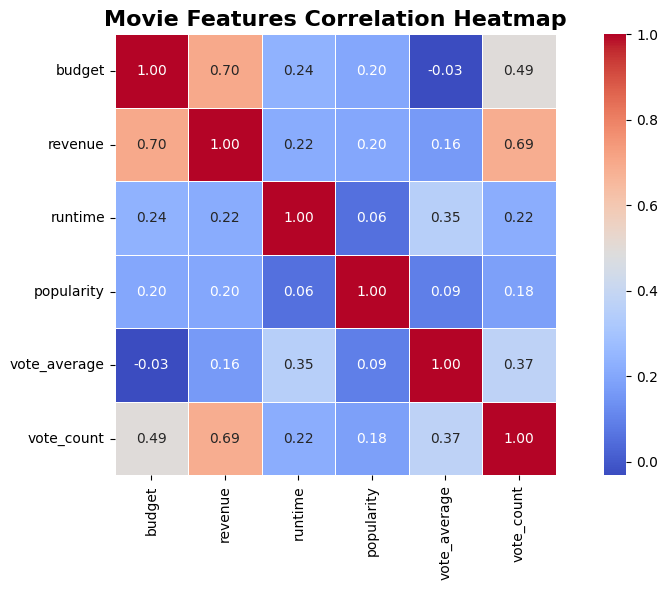

revenue         1.000000
budget          0.701106
vote_count      0.689123
runtime         0.215350
popularity      0.201648
vote_average    0.162313
Name: revenue, dtype: float64


In [12]:
# Correlation Heatmap
corr_cols = [
    'budget',
    'revenue',
    'runtime',
    'popularity',
    'vote_average',
    'vote_count'
]
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5,square=True)
plt.title('Movie Features Correlation Heatmap',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with Revenue
revenue_corr = (
    df[corr_cols]
    .corr()['revenue']
    .sort_values(ascending=False)
)
print(revenue_corr)

**Observation**
- Budget (0.70) has the strongest positive correlation with revenue.
- Vote Count (0.69) also has a very strong positive correlation with revenue.
- Runtime and Popularity show weak positive correlations.
- Vote Average has the weakest positive relationship with revenue.
- No feature shows a strong negative correlation with revenue.

*Chart-7: Revenue by Release Month*

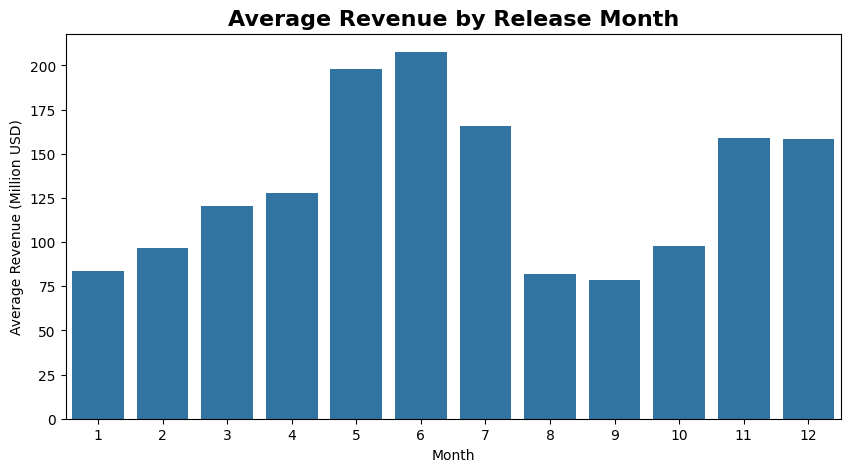

In [13]:
monthly_revenue = (df.groupby('release_month')['revenue'].mean()/1_000_000)
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_revenue.index,y=monthly_revenue.values)
plt.title('Average Revenue by Release Month',fontsize=16,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Revenue (Million USD)')
plt.show()

**Observation**
- Movies released in May (Month 5) and June (Month 6) generate the highest average revenue, with June showing the maximum average revenue of approximately $208 million.
- July (Month 7) also performs strongly, indicating that the summer period is highly profitable for movie releases.
- Movies released during November (Month 11) and December (Month 12) achieve relatively high average revenues, suggesting strong performance during the holiday season.
- The lowest average revenues are observed in August (Month 8) and September (Month 9), both below $85 million.
- Revenue generally increases from January through June, peaks during early summer, declines in late summer, and rises again during the year-end holiday period.

**EDA Conclusion**
- EDA revealed that **Budget** and **Vote Count** are the strongest predictors of movie revenue, while **Popularity**, **Ratings**, **Runtime**, **Release Date(Release Year and Month)**, and **Genre** also contribute valuable information. Therefore, these features were selected to build the Movie Revenue Prediction model.

**Feature Engineering**

*Log Transform Revenue and Budget*

In [14]:
df['log_revenue'] = np.log1p(df['revenue'])
df['log_budget'] = np.log1p(df['budget'])
df[['revenue','log_revenue']].head()

,revenue,log_revenue
0,10550000.0,16.171637
3,33392248.0,17.323834
5,409278201.0,19.829906
9,315648.0,12.662386
10,721046090.0,20.396214


*Year and Month Extraction(Already done in Data Cleaning Section)*

In [15]:
df[['release_date','release_year','release_month']].head()

,release_date,release_year,release_month
0,2025-03-31,2025,3
3,2025-03-26,2025,3
5,2025-02-12,2025,2
9,2025-01-13,2025,1
10,2024-12-18,2024,12


*Primary Genre Creation*

In [16]:
df['genres'] = df['genres'].apply(ast.literal_eval)
df['primary_genre'] = df['genres'].apply(lambda x: x[0] if len(x)>0 else 'Unknown')
df[['genres','primary_genre']].head()

,genres,primary_genre
0,"[Family, Comedy, Adventure, Fantasy]",Family
3,"[Action, Crime, Thriller]",Action
5,"[Action, Thriller, Science Fiction]",Action
9,"[Horror, Thriller, Fantasy]",Horror
10,"[Adventure, Family, Animation]",Adventure


*One-Hot Encode Genre*

In [17]:
genre_dummies = pd.get_dummies(df['primary_genre'],prefix='genre').astype(int)
df = pd.concat([df, genre_dummies],axis=1)
genre_dummies.head()

,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_Thriller,genre_Unknown,genre_War,genre_Western
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


*Selection and Scaling of Numerical Features*

In [18]:
#Feature Selection
numeric_features = [
    'log_budget',
    'popularity',
    'vote_average',
    'vote_count',
    'runtime',
    'release_year',
    'release_month'
]

#Feature Scaling
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
df[numeric_features].head()

,log_budget,popularity,vote_average,vote_count,runtime,release_year,release_month
0,1.341210,44.742480,-1.081630,-0.783487,-0.501514,1.228610,-1.197913
3,0.473852,22.973892,0.252301,-0.787556,0.183790,1.228610,-1.197913
5,1.460852,20.022688,-0.759469,-0.525506,0.320850,1.228610,-1.492387
9,-2.856556,14.401281,-0.782757,-0.806461,-1.049757,1.228610,-1.786860
10,1.529991,11.288297,0.958728,-0.370669,0.275163,1.167184,1.452347


*Final Feature List*

In [19]:
#Genre Columns
genre_columns = genre_dummies.columns.tolist()

#Final Feature Set
feature_columns = (numeric_features + genre_columns)

*Defining X and y*

In [20]:
X= df[feature_columns]
y= df['log_revenue']

#Verify the shapes of X and y
print('Shape of X: ',X.shape)
print('Shape of y: ',y.shape)

Shape of X:  (4604, 26)
Shape of y:  (4604,)


**Feature Engineering Summary**
- Applied log transformation to revenue and budget to reduce skewness.
- Extracted release year and release month from release date.
- Created primary genre feature.
- Applied one-hot encoding to genre categories.
- Standardized numerical features using StandardScaler.
- Final model used 26 features.

**Train-Test Split**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3683, 26)
X_test : (921, 26)
y_train: (3683,)
y_test : (921,)


**Building Model**

*Model-1: Linear Regression*

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("R²_LR :", r2_score(y_test, y_pred_lr))
print("MAE_LR:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE_LR:",np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R²_LR : 0.49612224930366255
MAE_LR: 0.9424796053797637
RMSE_LR: 1.3544991769378587


*Model-2: Random Forest*

In [23]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("R²_RF :", r2_score(y_test, y_pred_rf))
print("MAE_RF:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE_RF:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


R²_RF : 0.5444040378884327
MAE_RF: 0.8655058940385539
RMSE_RF: 1.2879710091558982


*Model Comparison Table*

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.496122,0.942480,1.354499
1,Random Forest,0.544404,0.865506,1.287971


**Observations**
- *Linear Regression*
  - Explains approximately 49.6% of the variance in movie revenue.
  - Average prediction error (MAE) is 0.94 in log-revenue units.
  - Serves as a good baseline model.
- *Random Forest*
  - Explains approximately 54.4% of the variance in movie revenue.
  - Achieves lower MAE and RMSE than Linear Regression.
  - Performs better at capturing non-linear relationships between features and revenue.

**Conclusion**
- Random Forest outperformed Linear Regression on all evaluation metrics.
- R² increased from 0.4961 to 0.5444.
- MAE decreased from 0.9425 to 0.8655.
- RMSE decreased from 1.3545 to 1.2880.

Therefore, Random Forest was selected as the final model for the Movie Revenue Predictor Dashboard.

**Feature Importance (Random Forest)**

*Feature Importance Code*

In [25]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
0,log_budget,0.422633
3,vote_count,0.251088
2,vote_average,0.073435
5,release_year,0.063754
1,popularity,0.059794
4,runtime,0.048942
6,release_month,0.030072
7,genre_Action,0.009476
10,genre_Comedy,0.005669
21,genre_Science Fiction,0.005167


*Visualization*

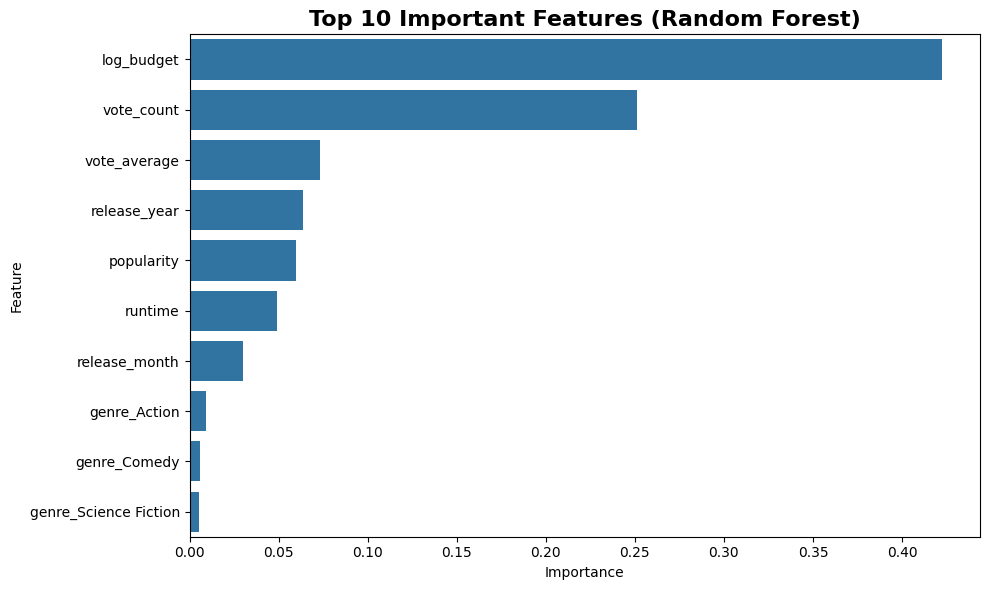

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10),x='Importance',y='Feature')
plt.title('Top 10 Important Features (Random Forest)',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

**Observation**
- **log_budget** is the most influential feature, contributing approximately 40% of the model's predictive power.
- **vote_count** is the second most important feature, indicating that audience engagement is strongly associated with movie revenue.
- **vote_average** contributes moderately, suggesting that movie quality has some influence on revenue.
- **release_year**, **popularity**, and **runtime** have moderate importance.
- Genre-related features contribute relatively less compared to numerical features.
- The model relies more on production and audience-related metrics than on genre alone.

**Saving the Random Forest Model**

In [27]:
#Saving the Model
pickle.dump(
    rf,
    open('movie_revenue_model.pkl', 'wb')
)
pickle.dump(
    scaler,
    open('scaler.pkl', 'wb')
)
pickle.dump(
    feature_columns,
    open('feature_columns.pkl', 'wb')
)

#Verifying the saved model
print(os.path.exists('movie_revenue_model.pkl'))

True


**Saving the Scaler**

In [28]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

**Saving Feature Columns**

In [29]:
pickle.dump(feature_columns,
            open('feature_columns.pkl', 'wb'))

**Final Conclusion**

A Movie Revenue Predictor Dashboard was successfully developed using machine learning techniques.

Random Forest achieved the best performance with:
- R² = 0.5444
- MAE = 0.8655
- RMSE = 1.2880

Feature importance analysis showed that budget and vote count are the strongest predictors of movie revenue. The trained model was deployed through an interactive Streamlit dashboard that allows users to estimate movie revenue based on movie characteristics.

**Test Case-1: Blockbuster Movie**

- Budget: 200000000
- Popularity: 80
- Vote Average: 8.0
- Vote Count: 12000
- Runtime: 150
- Release Year: 2019
- Release Month: 6
- Genre: Action

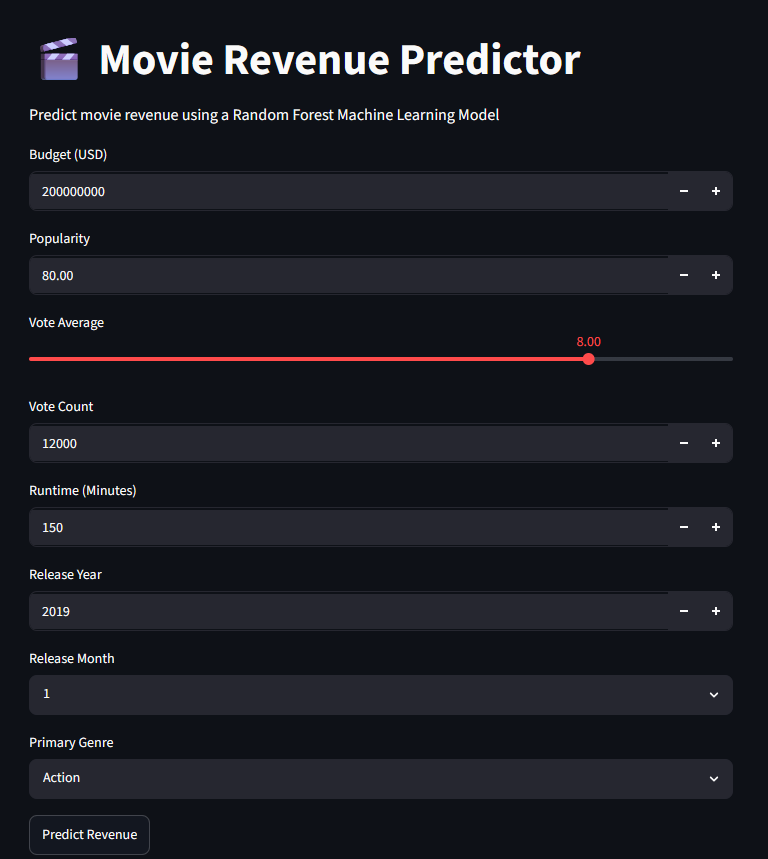
- Predicted Revenue: $1,259,549,530.33

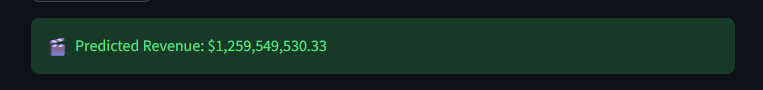

**Test Case-2: Successful Animated Film**

- Budget: 120000000
- Popularity: 70
- Vote Average: 8.2
- Vote Count: 8000
- Runtime: 110
- Release Year: 2021
- Release Month: 11
- Genre: Animation

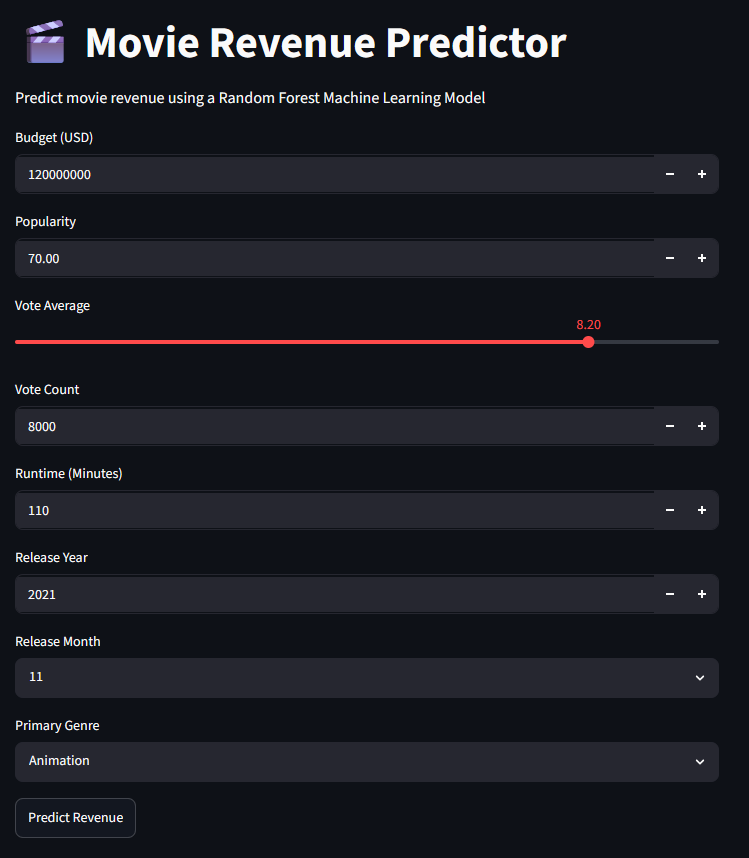

- Predicted Revenue: $445,432,970.26

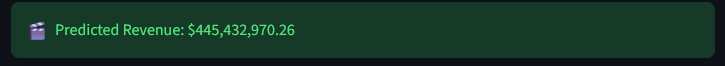

**Test Cas-3: Medium Budget Comedy**

- Budget: 30000000
- Popularity: 20
- Vote Average: 6.8
- Vote Count: 1500
- Runtime: 100
- Release Year: 2018
- Release Month: 3
- Genre: Comedy

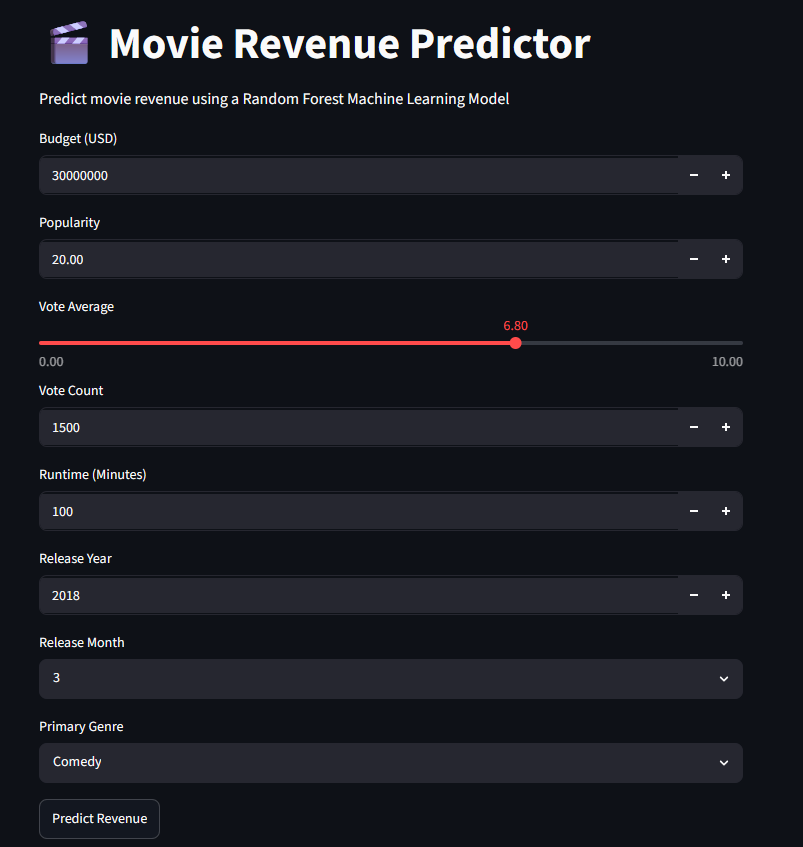

- Predicted Revenue: $29,198,612.76

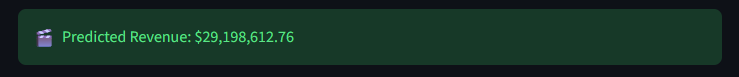

**Test Case 4: Low Budget Horror**

- Budget: 5000000
- Popularity: 10
- Vote Average: 6.2
- Vote Count: 500
- Runtime: 95
- Release Year: 2017
- Release Month: 9
- Genre: Horror

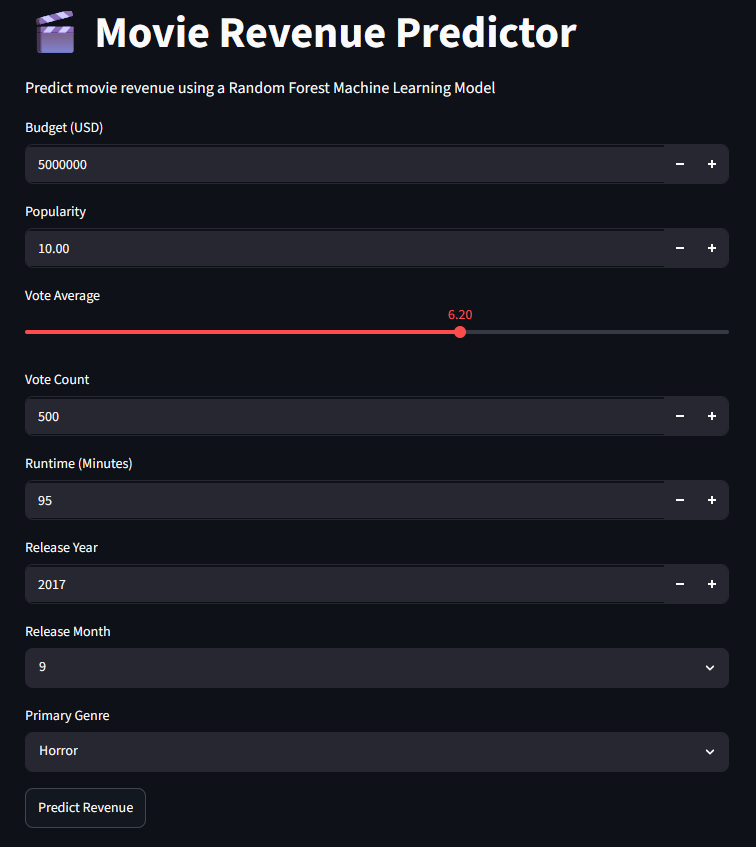

- Predicted Revenue: $2,553,623.64

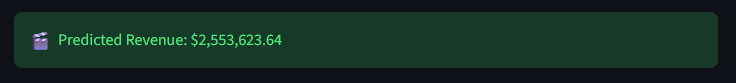

**Test Case-5: Poor Performing Movie**

- Budget: 10000000
- Popularity: 2
- Vote Average: 4.5
- Vote Count: 50
- Runtime: 90
- Release Year: 2015
- Release Month: 8
- Genre: Drama

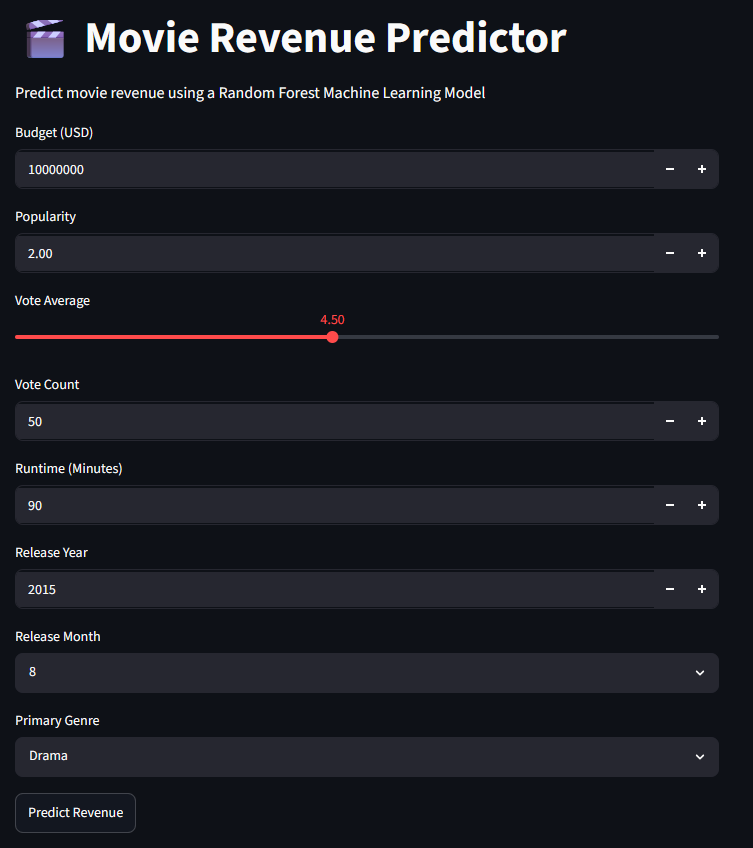

- Predicted Revenue: $1,615,479.79

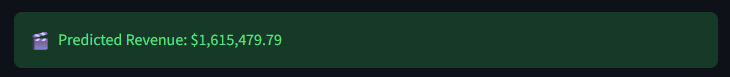

**Prediction Analysis**

- High-budget movies received significantly higher revenue predictions than low-budget movies.
- Movies with greater popularity, higher vote counts, and better ratings generally produced larger revenue estimates.
- Action, Adventure, and Animation movies showed stronger revenue potential compared to other genres.
- Low-budget movies with poor ratings and low popularity resulted in substantially lower predicted revenues.
- The prediction results align with the insights obtained from exploratory data analysis and feature importance analysis, indicating that the model captures meaningful patterns in the dataset.

**Conclusion**

- The Random Forest model successfully predicts movie revenue using movie-related features.
- Budget and audience engagement metrics were identified as the most influential factors affecting revenue.
- The Streamlit dashboard provides an interactive and user-friendly interface for generating revenue predictions.
- The project demonstrates the complete data science workflow, including data preprocessing, exploratory analysis, feature engineering, model development, evaluation, and deployment.

**Hyperparameter Tuning**

*Defining the Parameter Grid*

In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None]
}

*Creating GridSearchCV*

In [33]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

**Meaning of each parameter**
- cv=5 → 5-fold cross-validation
- scoring='neg_root_mean_squared_error'→ Optimize for the lowest RMSE
- n_jobs=-1 → Use all CPU cores
- estimator → The Random Forest model being tuned

*Training Grid Search*

In [34]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

*Displaying the Best Parameters*

In [35]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'n_estimators': 300}


*Best Model*

In [36]:
best_rf = grid_search.best_estimator_

*Prediction*

In [37]:
y_pred_best = best_rf.predict(X_test)

*Evaluation*

In [38]:
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = root_mean_squared_error(y_test, y_pred_best)

print("Tuned Random Forest Results")
print("----------------------------")
print("R² :", round(r2,4))
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))

Tuned Random Forest Results
----------------------------
R² : 0.5425
MAE: 0.8666
RMSE: 1.2906


*Comparison*

In [39]:
comparison = pd.DataFrame({
    'Model': ['Random Forest (Before)', 'Random Forest (After GridSearch)'],
    'R²': [0.5444, r2],
    'MAE': [0.8655, mae],
    'RMSE': [1.2880, rmse]
})

comparison

,Model,R²,MAE,RMSE
0,Random Forest (Before),0.544400,0.865500,1.288000
1,Random Forest (After GridSearch),0.542522,0.866641,1.290628


**Interpretation**
- R²: Decreased slightly (0.5444 → 0.5425)
- MAE: Increased slightly (0.8655 → 0.8666)
- RMSE: Increased slightly (1.2880 → 1.2906)

**Observations**
- GridSearchCV identified the best hyperparameters as n_estimators = 300 and max_depth = 20.
- The tuned Random Forest model achieved an R² score of 0.5425, which is slightly lower than the original model (0.5444).
- The MAE increased slightly from 0.8655 to 0.8666, indicating a marginal increase in average prediction error.
- The RMSE increased slightly from 1.2880 to 1.2906, showing a very small decline in prediction accuracy.
- The performance difference between the original and tuned models is minimal, indicating that the original Random Forest model was already well-configured.
- Since the original model produced slightly better evaluation metrics, it was retained as the final model for deployment in the Streamlit dashboard.